In [76]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [ ]:
pathdir_old_ds = "Y:/TwoDGas/2025/07/04"
pathdir_new_ds = "Y:/TwoDGas/2026/01/19/0046"
pathdir_BEC_ds = "Y:/TwoDGas/2026/01/19/0047"
pathdir_tilted_15_ds =  "Y:/StructuralPhaseTransition/2026/02/02/0000"

N = 30
n0 = 1279#1e1
r = 100
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz
N_atoms_per_droplet = 15000

ω0 = 2π*ustrip(c_0)/λ

x_crop = [1100:1700;]
y_crop = [1750:2450;]

Isat = ustrip(ħ)*Γ*ω0^3 / (12*π*ustrip(c_0)^2)
Isat /= ustrip(ħ)*ω0*N_atoms_per_droplet; # Convert to photon/m^2/atom;

### Load experimental data

In [62]:
# Old dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_old_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_old_ds, Iatoms_old_ds, Ibkg_old_ds, Idark_old_ds, Mean_atoms_old_ds, Mean_bkg_old_ds, Mean_dark_old_ds, Mean_bkg_atoms_old_ds, Std_atoms_old_ds, Std_bkg_old_ds, Std_dark_old_ds, Std_bkg_atoms_old_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

In [63]:
# New dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_new_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_new_ds, Iatoms_new_ds, Ibkg_new_ds, Idark_new_ds, Mean_atoms_new_ds, Mean_bkg_new_ds, Mean_dark_new_ds, Mean_bkg_atoms_new_ds, Std_atoms_new_ds, Std_bkg_new_ds, Std_dark_new_ds, Std_bkg_atoms_new_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

In [64]:
# BEC dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_BEC_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_BEC_ds, Iatoms_BEC_ds, Ibkg_BEC_ds, Idark_BEC_ds, Mean_atoms_BEC_ds, Mean_bkg_BEC_ds, Mean_dark_BEC_ds, Mean_bkg_atoms_BEC_ds, Std_atoms_BEC_ds, Std_bkg_BEC_ds, Std_dark_BEC_ds, Std_bkg_atoms_BEC_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

In [65]:
# Tilted_15 dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_tilted_15_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_tilted_15_ds, Iatoms_tilted_15_ds, Ibkg_tilted_15_ds, Idark_tilted_15_ds, Mean_atoms_tilted_15_ds, Mean_bkg_tilted_15_ds, Mean_dark_tilted_15_ds, Mean_bkg_atoms_tilted_15_ds, Std_atoms_tilted_15_ds, Std_bkg_tilted_15_ds, Std_dark_tilted_15_ds, Std_bkg_atoms_tilted_15_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

### Load simulations

In [66]:
@load "Solutions_sim/Itot_N_$(N)_r_100_sat_[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]_n0_$(n0)_decay_rate_up_down.jdl2" Sat Itot I_SE_SR_SS I_SR_SR_SS nbr_error_t_N;

### Plot the experimental data

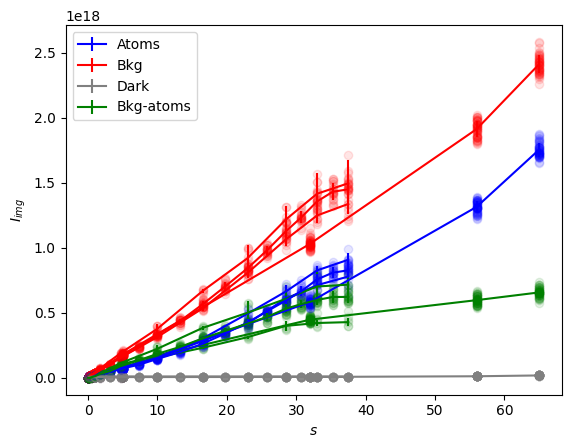

In [67]:
close("all")
fig = subplots()

# Old dataset
errorbar(Sat_old_ds, Mean_atoms_old_ds, yerr=Std_atoms_old_ds, label="Atoms", color="b")
errorbar(Sat_old_ds, Mean_bkg_old_ds, yerr=Std_bkg_old_ds, label="Bkg", color="r")
errorbar(Sat_old_ds, Mean_dark_old_ds, yerr=Std_dark_old_ds, label="Dark", color="grey")
errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Iatoms_old_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_old_ds[i], Idark_old_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(Sat_new_ds, Mean_atoms_new_ds, yerr=Std_atoms_new_ds, color="b")
errorbar(Sat_new_ds, Mean_bkg_new_ds, yerr=Std_bkg_new_ds, color="r")
errorbar(Sat_new_ds, Mean_dark_new_ds, yerr=Std_dark_new_ds, color="grey")
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Iatoms_new_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_new_ds[i], Idark_new_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end

# BEC dataset
errorbar(Sat_BEC_ds, Mean_atoms_BEC_ds, yerr=Std_atoms_BEC_ds, color="b")
errorbar(Sat_BEC_ds, Mean_bkg_BEC_ds, yerr=Std_bkg_BEC_ds, color="r")
errorbar(Sat_BEC_ds, Mean_dark_BEC_ds, yerr=Std_dark_BEC_ds, color="grey")
errorbar(Sat_BEC_ds, Mean_bkg_atoms_BEC_ds, yerr=Std_bkg_atoms_BEC_ds, color="green")

for i = 1:length(Sat_BEC_ds)
    for j = 1:size(Iatoms_BEC_ds)[2]
        scatter(Sat_BEC_ds[i], Iatoms_BEC_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_BEC_ds[i], Ibkg_BEC_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_BEC_ds[i], Idark_BEC_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_BEC_ds[i], Ibkg_BEC_ds[i, j]-Iatoms_BEC_ds[i, j], color="g", alpha = 0.1)
    end
end

# Tilted 15 dataset
errorbar(Sat_tilted_15_ds, Mean_atoms_tilted_15_ds, yerr=Std_atoms_tilted_15_ds, color="b")
errorbar(Sat_tilted_15_ds, Mean_bkg_tilted_15_ds, yerr=Std_bkg_tilted_15_ds, color="r")
errorbar(Sat_tilted_15_ds, Mean_dark_tilted_15_ds, yerr=Std_dark_tilted_15_ds, color="grey")
errorbar(Sat_tilted_15_ds, Mean_bkg_atoms_tilted_15_ds, yerr=Std_bkg_atoms_tilted_15_ds, color="green")

for i = 1:length(Sat_tilted_15_ds)
    for j = 1:size(Iatoms_tilted_15_ds)[2]
        scatter(Sat_tilted_15_ds[i], Iatoms_tilted_15_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_tilted_15_ds[i], Ibkg_tilted_15_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_tilted_15_ds[i], Idark_tilted_15_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_tilted_15_ds[i], Ibkg_tilted_15_ds[i, j]-Iatoms_tilted_15_ds[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Bkg-atoms

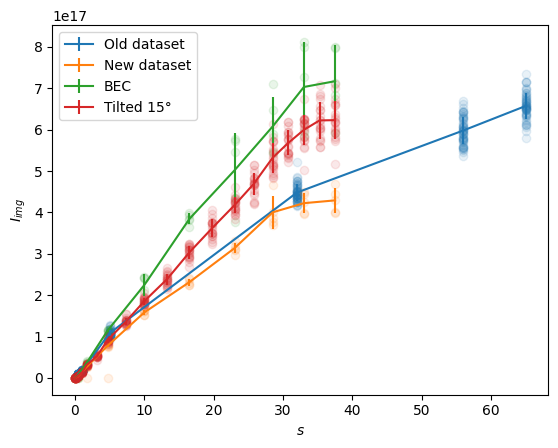

In [68]:
close("all")
fig = subplots()

# Old dataset
line_old, = errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Old dataset")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], alpha = 0.1, color=line_old.get_color())
    end
end

# New dataset
line_new, = errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, label="New dataset")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color=line_new.get_color(), alpha = 0.1)
    end
end

# BEC dataset
line_BEC, = errorbar(Sat_BEC_ds, Mean_bkg_atoms_BEC_ds, yerr=Std_bkg_atoms_BEC_ds, label="BEC")

for i = 1:length(Sat_BEC_ds)
    for j = 1:size(Iatoms_BEC_ds)[2]
        scatter(Sat_BEC_ds[i], Ibkg_BEC_ds[i, j]-Iatoms_BEC_ds[i, j], color=line_BEC.get_color(), alpha = 0.1)
    end
end

# Tilted 15 dataset
line_tilted_15, = errorbar(Sat_tilted_15_ds, Mean_bkg_atoms_tilted_15_ds, yerr=Std_bkg_atoms_tilted_15_ds, label="Tilted 15°")

for i = 1:length(Sat_tilted_15_ds)
    for j = 1:size(Iatoms_tilted_15_ds)[2]
        scatter(Sat_tilted_15_ds[i], Ibkg_tilted_15_ds[i, j]-Iatoms_tilted_15_ds[i, j], color=line_tilted_15.get_color(), alpha = 0.1)
    end
end


# # Simulations
# errorbar(Sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

# for i in 1:length(Sat)
#     for j in 1:r
#         if j ∉ nbr_error_t_N[i]
#             scatter(Sat[i], Itot[i, j], alpha=0.1, color="blue")
#         end
#     end
# end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

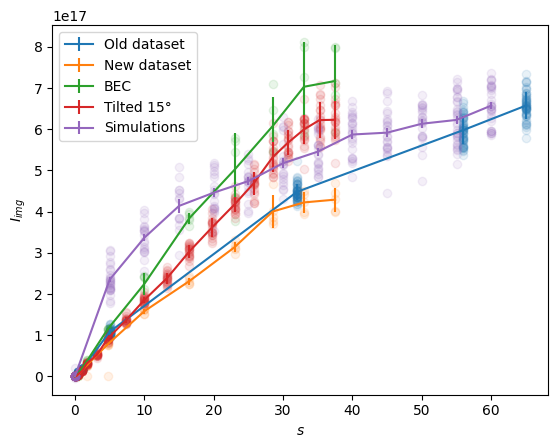

In [69]:
factor_prop = maximum(Mean_bkg_atoms_old_ds)/maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)])

close("all")
fig = subplots()

# Old dataset
line_old, = errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Old dataset")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], alpha = 0.1, color=line_old.get_color())
    end
end

# New dataset
line_new, = errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, label="New dataset")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color=line_new.get_color(), alpha = 0.1)
    end
end

# BEC dataset
line_BEC, = errorbar(Sat_BEC_ds, Mean_bkg_atoms_BEC_ds, yerr=Std_bkg_atoms_BEC_ds, label="BEC")

for i = 1:length(Sat_BEC_ds)
    for j = 1:size(Iatoms_BEC_ds)[2]
        scatter(Sat_BEC_ds[i], Ibkg_BEC_ds[i, j]-Iatoms_BEC_ds[i, j], color=line_BEC.get_color(), alpha = 0.1)
    end
end

# Tilted 15 dataset
line_tilted_15, = errorbar(Sat_tilted_15_ds, Mean_bkg_atoms_tilted_15_ds, yerr=Std_bkg_atoms_tilted_15_ds, label="Tilted 15°")

for i = 1:length(Sat_tilted_15_ds)
    for j = 1:size(Iatoms_tilted_15_ds)[2]
        scatter(Sat_tilted_15_ds[i], Ibkg_tilted_15_ds[i, j]-Iatoms_tilted_15_ds[i, j], color=line_tilted_15.get_color(), alpha = 0.1)
    end
end


# Simulations
line_sim, = errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color=line_sim.get_color())
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

In [70]:
factor_prop

0.005034535930945687

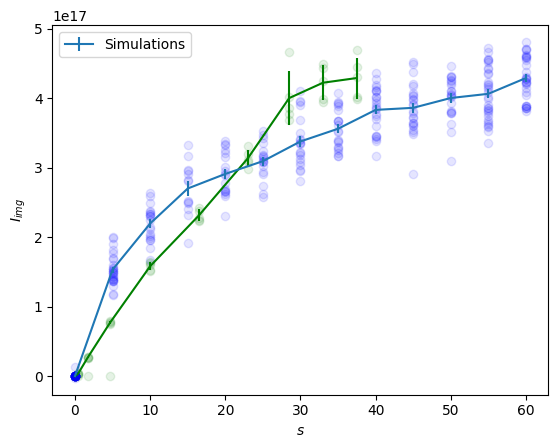

In [71]:
factor_prop = maximum(Mean_bkg_atoms_new_ds)/maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)])

close("all")
fig = subplots()

# Old dataset
# errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

# for i = 1:length(Sat_old_ds)
#     for j = 1:size(Iatoms_old_ds)[2]
#         scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
#     end
# end

# New dataset
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end


# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

In [72]:
factor_prop

0.0032858689726412557

### Atoms

In [73]:
factor_prop = maximum(Mean_bkg_atoms_old_ds)/maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)])

close("all")
fig = subplots()

# # Old dataset
# line_old, = errorbar(Sat_old_ds, Mean_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Old dataset")

# for i = 1:length(Sat_old_ds)
#     for j = 1:size(Iatoms_old_ds)[2]
#         scatter(Sat_old_ds[i], Iatoms_old_ds[i, j], alpha = 0.1, color=line_old.get_color())
#     end
# end

# New dataset
line_new, = errorbar(Sat_new_ds, Mean_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, label="New dataset")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Iatoms_new_ds[i, j], color=line_new.get_color(), alpha = 0.1)
    end
end

# BEC dataset
line_BEC, = errorbar(Sat_BEC_ds, Mean_atoms_BEC_ds, yerr=Std_bkg_atoms_BEC_ds, label="BEC")

for i = 1:length(Sat_BEC_ds)
    for j = 1:size(Iatoms_BEC_ds)[2]
        scatter(Sat_BEC_ds[i], Iatoms_BEC_ds[i, j], color=line_BEC.get_color(), alpha = 0.1)
    end
end

# Tilted 15 dataset
line_tilted_15, = errorbar(Sat_tilted_15_ds, Mean_atoms_tilted_15_ds, yerr=Std_bkg_atoms_tilted_15_ds, label="Tilted 15°")

for i = 1:length(Sat_tilted_15_ds)
    for j = 1:size(Iatoms_tilted_15_ds)[2]
        scatter(Sat_tilted_15_ds[i], Iatoms_tilted_15_ds[i, j], color=line_tilted_15.get_color(), alpha = 0.1)
    end
end


# # Simulations
# line_sim, = errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

# for i in 1:length(Sat)
#     for j in 1:r
#         if j ∉ nbr_error_t_N[i]
#             scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color=line_sim.get_color())
#         end
#     end
# end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

pygui(true); show();
# pygui(false);

### Plot as a function of Sat measured from the images bkg

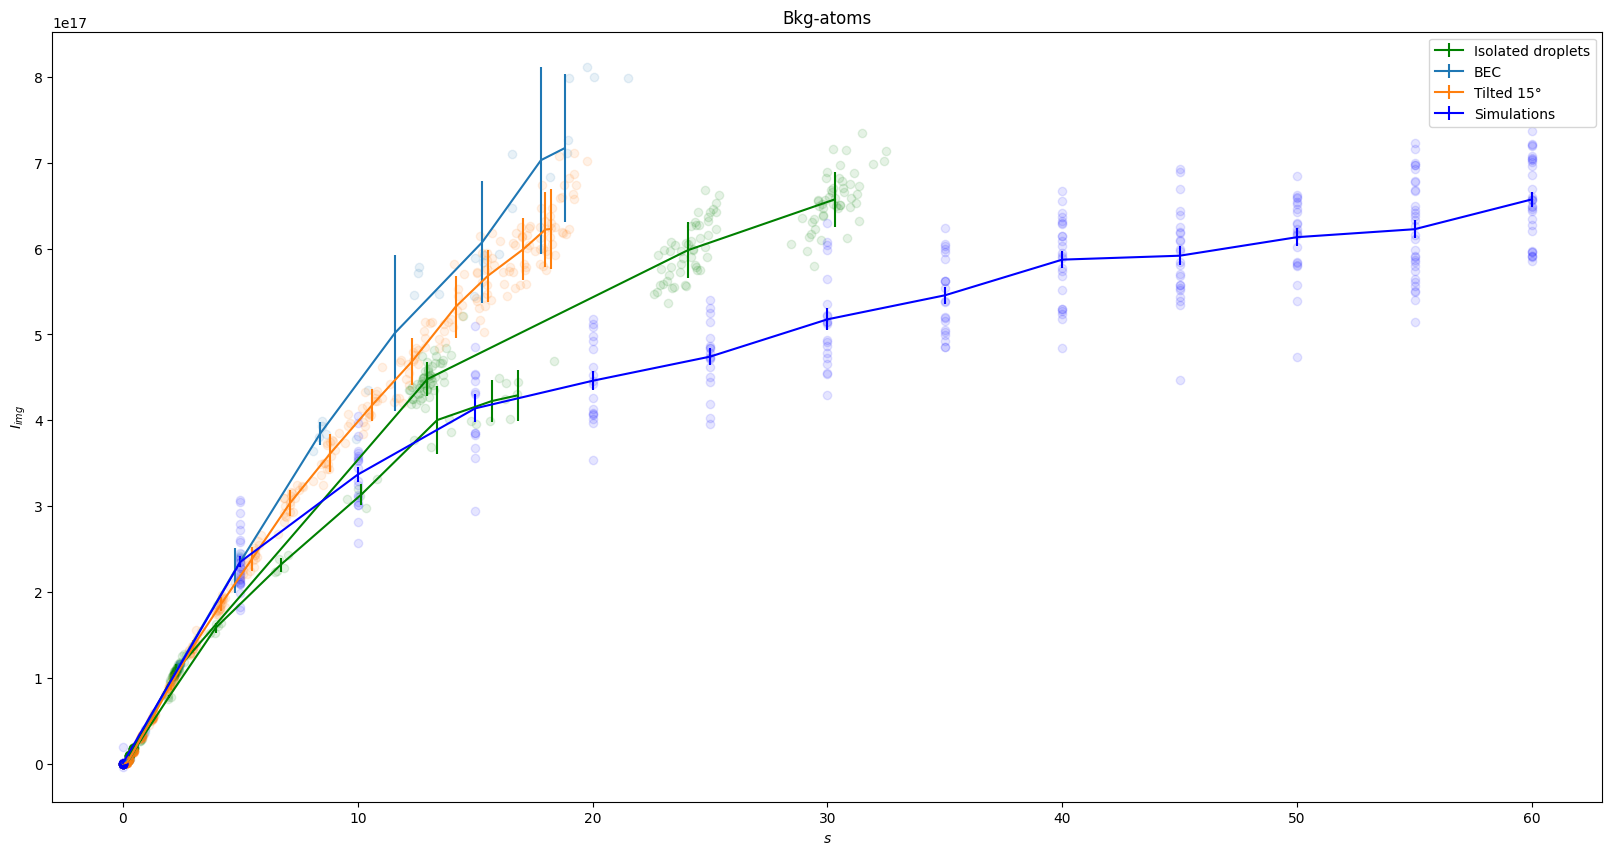

In [75]:
close("all")
fig = subplots(figsize=(20, 10))
title("Bkg-atoms")

# Old dataset
# errorbar(Mean_bkg_old_ds/Isat, Mean_atoms_old_ds, yerr=Std_atoms_old_ds, label="Atoms", color="b")
# errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_old_ds, yerr=Std_bkg_old_ds, color="r", label="Bkg")
# errorbar(Mean_bkg_old_ds/Isat, Mean_dark_old_ds, yerr=Std_dark_old_ds, label="Dark", color="grey")
errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Isolated droplets", color="green")


for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        # scatter(Mean_bkg_old_ds[i]/Isat, Iatoms_old_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Ibkg_old_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Idark_old_ds[i, j], color="grey", alpha = 0.1)
        scatter(Ibkg_old_ds[i, j]/Isat, Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
# errorbar(Mean_bkg_new_ds/Isat, Mean_atoms_new_ds, yerr=Std_atoms_new_ds, color="b")
# errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_new_ds, yerr=Std_bkg_new_ds, color="r")
# errorbar(Mean_bkg_new_ds/Isat, Mean_dark_new_ds, yerr=Std_dark_new_ds, color="grey")
errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        # scatter(Mean_bkg_new_ds[i]/Isat, Iatoms_new_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Ibkg_new_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Idark_new_ds[i, j], color="grey", alpha = 0.1)
        scatter(Ibkg_new_ds[i, j]/Isat, Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end


# BEC dataset
line_BEC, = errorbar(Mean_bkg_BEC_ds/Isat, Mean_bkg_atoms_BEC_ds, yerr=Std_bkg_atoms_BEC_ds, label="BEC")

for i = 1:length(Sat_BEC_ds)
    for j = 1:size(Iatoms_BEC_ds)[2]
        scatter(Ibkg_BEC_ds[i, j]/Isat, Ibkg_BEC_ds[i, j] - Iatoms_BEC_ds[i, j], color=line_BEC.get_color(), alpha = 0.1)
    end
end

# Tilted 15 dataset
line_tilted_15, = errorbar(Mean_bkg_tilted_15_ds/Isat, Mean_bkg_atoms_tilted_15_ds, yerr=Std_bkg_atoms_tilted_15_ds, label="Tilted 15°")

for i = 1:length(Sat_tilted_15_ds)
    for j = 1:size(Iatoms_tilted_15_ds)[2]
        scatter(Ibkg_tilted_15_ds[i, j]/Isat, Ibkg_tilted_15_ds[i, j]-Iatoms_tilted_15_ds[i, j], color=line_tilted_15.get_color(), alpha = 0.1)
    end
end

# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations", color="b")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);